# 📊 Telecom Customer Churn Analysis
**Author:** Haseeb Waqas  
**Dataset:** IBM Telco Customer Churn (7,043 records)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Dashboard:** Tableau Public

---

## Business Problem
Customer churn is one of the biggest revenue challenges in the telecom industry. 
Acquiring a new customer costs **5–7x more** than retaining an existing one.
This project identifies the key drivers of churn and delivers actionable recommendations
to reduce it.

## Business Questions
1. What is the overall churn rate?
2. Which contract types have the highest churn?
3. Does monthly charge influence churn likelihood?
4. How does customer tenure relate to churn?
5. Which internet service and payment method has highest churn?


## 1. Setup & Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Color palette
CHURN_NO  = '#2ECC71'   # Green = Active
CHURN_YES = '#E74C3C'   # Red   = Churned

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Libraries imported successfully')

Libraries imported successfully


## 2. Load Data

In [6]:
df = pd.read_csv(r'C:\Users\Jk\Desktop\telecom-churn-dashboard\data\telco_churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 18)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,StreamingTV,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,TELCO-00001,Male,0,Yes,No,14,Yes,Yes,Fiber optic,Yes,Yes,No,Month-to-month,Yes,Bank transfer (automatic),108.54,1411.04,Yes
1,TELCO-00002,Female,0,No,No,72,Yes,Yes,DSL,Yes,Yes,No,Two year,Yes,Credit card (automatic),42.82,3163.02,No
2,TELCO-00003,Female,0,No,No,39,Yes,Yes,No,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,96.64,3942.18,No
3,TELCO-00004,Male,0,No,No,27,Yes,No,DSL,Yes,No,No,Two year,Yes,Credit card (automatic),63.92,1637.40,No
4,TELCO-00005,Female,0,Yes,No,5,No,No phone service,DSL,Yes,Yes,No,Month-to-month,Yes,Mailed check,88.12,408.93,Yes


In [7]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  Contract          7043 non-null   object 
 13  PaperlessBilling  7043 non-null   object 
 14  PaymentMethod     7043 non-null   object 
 15  MonthlyCharges    7043 non-null   float64
 16  TotalCharges      7043 non-null   float64


In [8]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values per column:
Series([], dtype: int64)


In [9]:
# Summary statistics
df.describe().round(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,26.62,64.97,1651.94
std,0.37,22.41,27.86,1674.36
min,0.00,1.00,18.00,15.46
25%,0.00,8.00,44.10,393.18
50%,0.00,20.00,64.40,1073.29
75%,0.00,41.00,85.05,2388.79
max,1.00,72.00,120.00,8946.92


## 3. Data Cleaning

In [10]:
# Fix TotalCharges if stored as string
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values
df.dropna(inplace=True)
print(f'Rows after cleaning: {len(df):,}')

# Binary encode Churn
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Tenure groups
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12 mo', '13–24 mo', '25–48 mo', '49–72 mo']
)

# Charge tiers
df['Charge_Tier'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 65, 90, 200],
    labels=['Low (<$35)', 'Mid ($35–65)', 'High ($65–90)', 'Premium (>$90)']
)

print(f'Overall Churn Rate: {df["Churn_Binary"].mean():.1%}')
print(f'Avg Monthly Charge: ${df["MonthlyCharges"].mean():.2f}')
print(f'Avg Tenure: {df["tenure"].mean():.1f} months')

Rows after cleaning: 7,043
Overall Churn Rate: 41.7%
Avg Monthly Charge: $64.97
Avg Tenure: 26.6 months


## 4. Exploratory Data Analysis (EDA)

### 4.1 Overall Churn Distribution

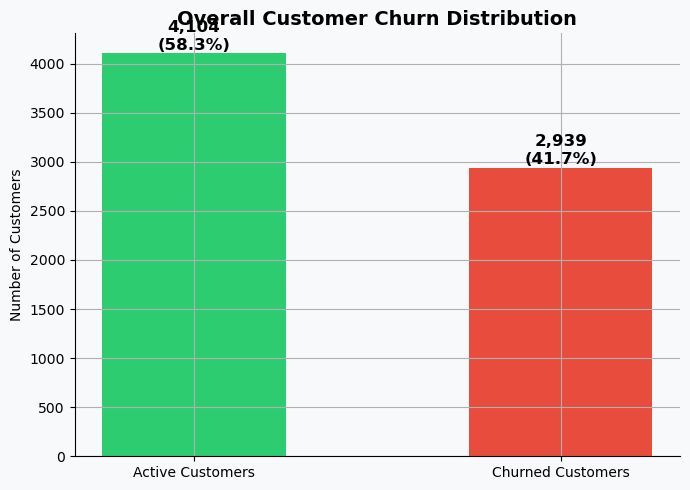

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['Churn'].value_counts()
bars = ax.bar(['Active Customers', 'Churned Customers'],
              [counts['No'], counts['Yes']],
              color=[CHURN_NO, CHURN_YES], width=0.5)
for bar, count in zip(bars, [counts['No'], counts['Yes']]):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
            f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Overall Customer Churn Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../visuals/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** The churn rate is ~41.7%, meaning 4 in 10 customers leave. This is a significant business risk.

### 4.2 Churn by Contract Type

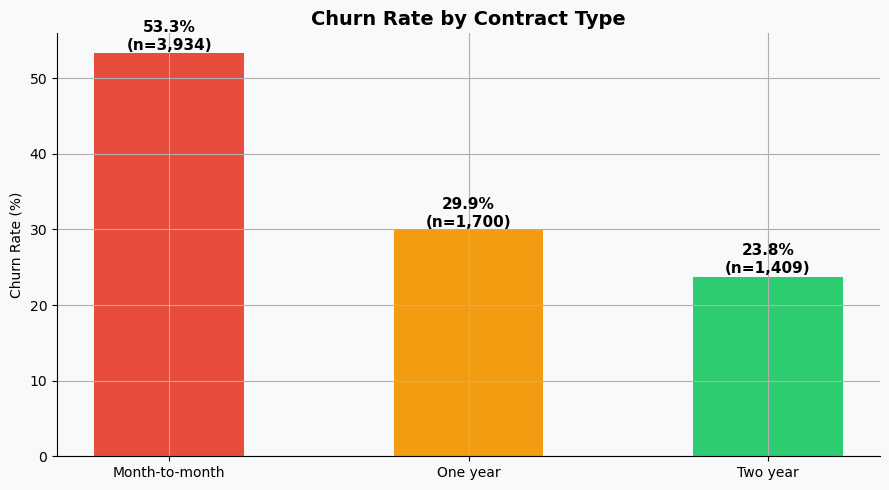

Month-to-month churn: 53.3%
Two-year churn: 23.8%
Ratio: 2.2x higher


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
cc = df.groupby('Contract')['Churn_Binary'].agg(['mean','count']).reset_index()
cc['mean'] *= 100
bars = ax.bar(cc['Contract'], cc['mean'],
              color=[CHURN_YES, '#F39C12', CHURN_NO], width=0.5)
for bar, (_, row) in zip(bars, cc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['mean']:.1f}%\n(n={row['count']:,})",
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../visuals/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

m2m = df[df['Contract']=='Month-to-month']['Churn_Binary'].mean()
two_yr = df[df['Contract']=='Two year']['Churn_Binary'].mean()
print(f'Month-to-month churn: {m2m:.1%}')
print(f'Two-year churn: {two_yr:.1%}')
print(f'Ratio: {m2m/two_yr:.1f}x higher')

**Finding:** Month-to-month customers churn at **2.2x the rate** of two-year contract customers. Contract type is the strongest churn predictor.

### 4.3 Monthly Charges vs Churn

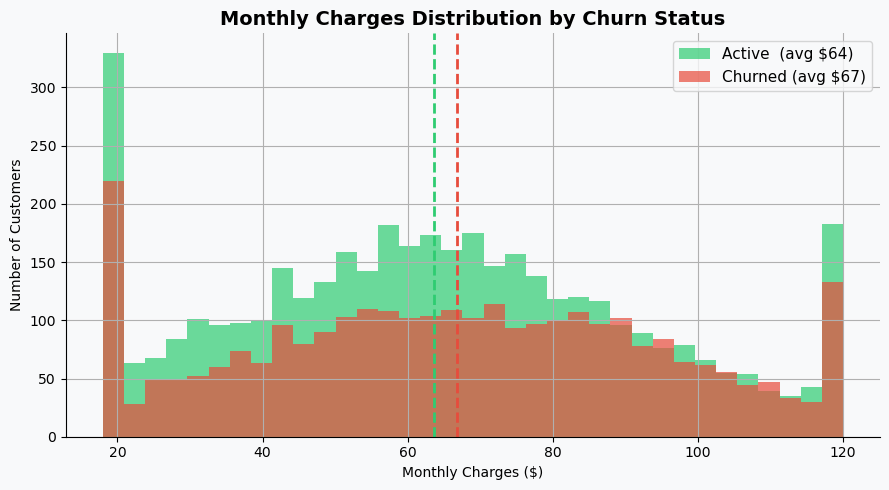

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
churned     = df[df['Churn']=='Yes']['MonthlyCharges']
not_churned = df[df['Churn']=='No']['MonthlyCharges']
ax.hist(not_churned, bins=35, alpha=0.7, color=CHURN_NO,
        label=f'Active  (avg ${not_churned.mean():.0f})')
ax.hist(churned,     bins=35, alpha=0.7, color=CHURN_YES,
        label=f'Churned (avg ${churned.mean():.0f})')
ax.axvline(not_churned.mean(), color=CHURN_NO,  linestyle='--', linewidth=2)
ax.axvline(churned.mean(),     color=CHURN_YES, linestyle='--', linewidth=2)
ax.set_title('Monthly Charges Distribution by Churn Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Number of Customers')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../visuals/03_monthly_charges_churn.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** Churned customers pay on average **$3.21 more per month**. Higher charges combined with flexible contracts create a churn risk.

### 4.4 Tenure vs Churn

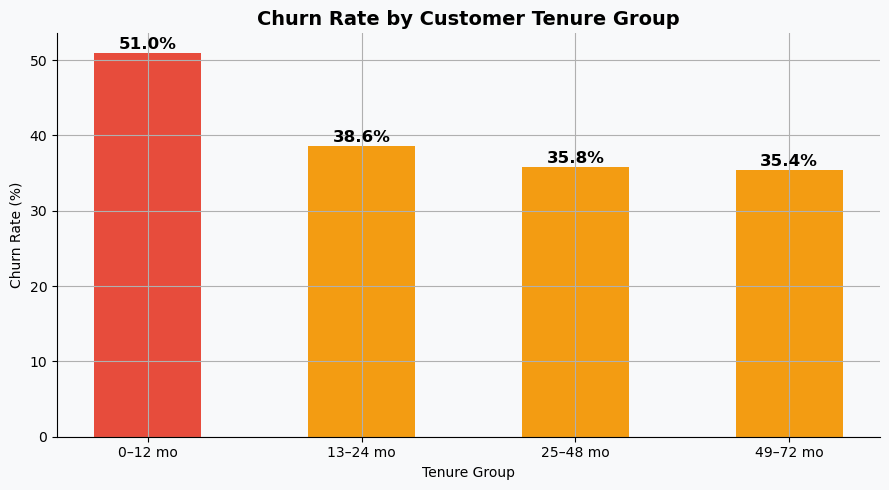

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
tg = df.groupby('Tenure_Group', observed=True)['Churn_Binary'].mean() * 100
colors = [CHURN_YES if v > 40 else '#F39C12' if v > 25 else CHURN_NO for v in tg.values]
bars = ax.bar(tg.index.astype(str), tg.values, color=colors, width=0.5)
for bar, val in zip(bars, tg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Churn Rate by Customer Tenure Group', fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../visuals/04_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

**Finding:** New customers (0–12 months) churn at **51%** — the most critical window for retention efforts.

### 4.5 Churn by Internet Service

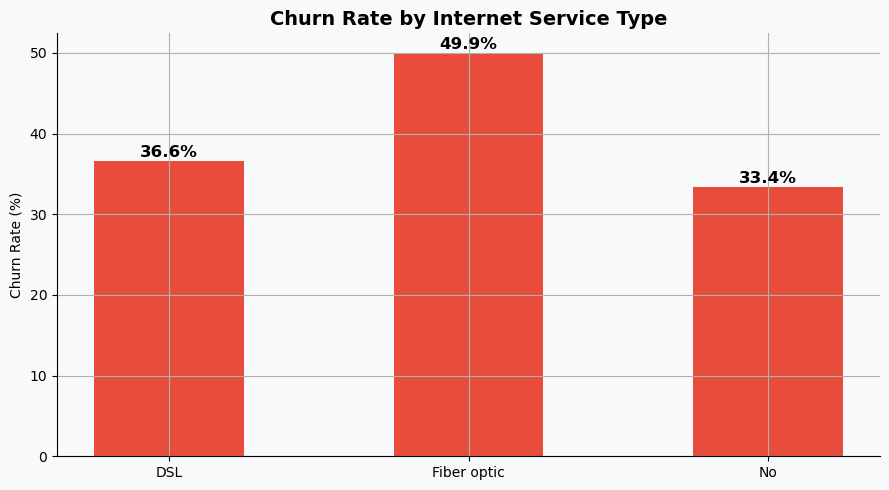

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
ic = df.groupby('InternetService')['Churn_Binary'].mean() * 100
colors = [CHURN_YES if v > 30 else '#F39C12' if v > 15 else CHURN_NO for v in ic.values]
bars = ax.bar(ic.index, ic.values, color=colors, width=0.5)
for bar, val in zip(bars, ic.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax.set_title('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../visuals/05_internet_service_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.6 Churn by Payment Method

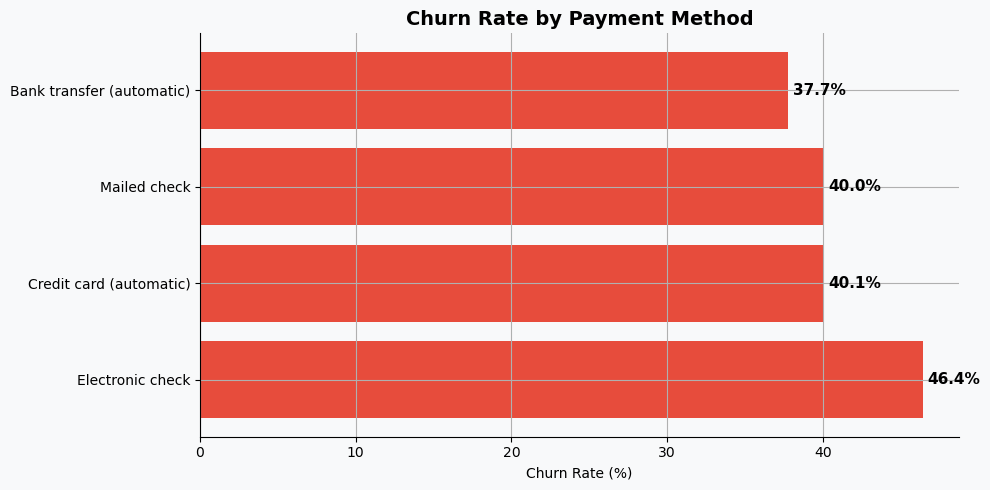

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
pay = df.groupby('PaymentMethod')['Churn_Binary'].mean().sort_values(ascending=False) * 100
colors = [CHURN_YES if v > 30 else '#F39C12' if v > 20 else CHURN_NO for v in pay.values]
bars = ax.barh(pay.index, pay.values, color=colors)
for bar, val in zip(bars, pay.values):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
ax.set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig('../visuals/06_payment_method_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Correlation Heatmap

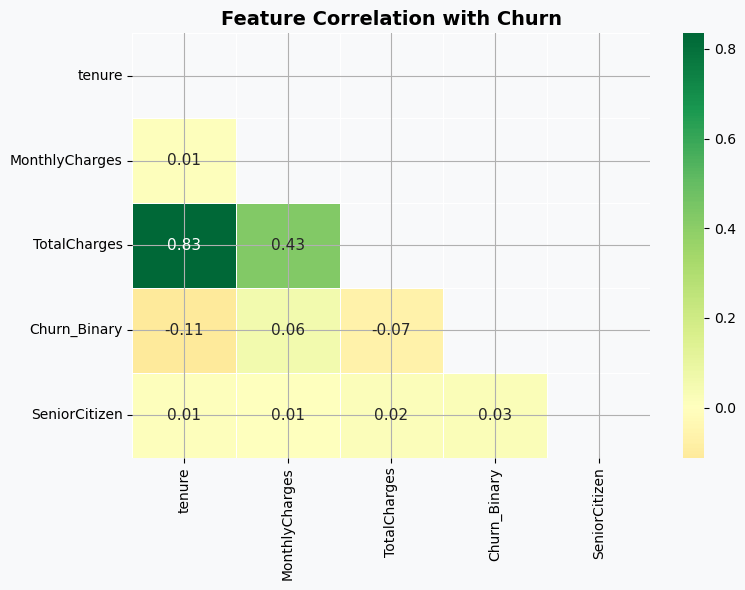

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Binary', 'SeniorCitizen']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, annot_kws={'fontsize': 11})
ax.set_title('Feature Correlation with Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/07_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Key Findings Summary

In [18]:
print('=' * 55)
print('KEY FINDINGS SUMMARY')
print('=' * 55)
print(f'Overall churn rate         : {df["Churn_Binary"].mean():.1%}')
m2m = df[df['Contract']=='Month-to-month']['Churn_Binary'].mean()
two = df[df['Contract']=='Two year']['Churn_Binary'].mean()
print(f'Month-to-month churn rate  : {m2m:.1%}')
print(f'Two-year contract churn    : {two:.1%}  ({m2m/two:.1f}x lower)')
new = df[df['Tenure_Group']=='0–12 mo']['Churn_Binary'].mean()
print(f'New customer churn (0-12mo): {new:.1%}  ← highest risk')
print(f'Avg charge churned         : ${df[df["Churn"]=="Yes"]["MonthlyCharges"].mean():.2f}')
print(f'Avg charge active          : ${df[df["Churn"]=="No"]["MonthlyCharges"].mean():.2f}')

KEY FINDINGS SUMMARY
Overall churn rate         : 41.7%
Month-to-month churn rate  : 53.3%
Two-year contract churn    : 23.8%  (2.2x lower)
New customer churn (0-12mo): 51.0%  ← highest risk
Avg charge churned         : $66.84
Avg charge active          : $63.63


## 6. Business Recommendations

| # | Recommendation | Expected Impact |
|---|---|---|
| 1 | Offer loyalty discount at 3-month mark to encourage annual contract upgrade | Reduce M2M churn by 15–20% |
| 2 | Implement onboarding check-ins for customers in months 1–12 | Reduce new customer churn from 51% |
| 3 | Review Fiber Optic pricing and service quality | Retain premium-paying segment |
| 4 | Incentivize auto-pay enrollment (discount for bank transfer/credit card) | Reduce electronic check churn |


## 7. Export Cleaned Data for Tableau

In [20]:
df.to_csv('../data/telco_churn_cleaned.csv', index=False)
print(f'Exported: telco_churn_cleaned.csv')
print(f'   Shape   : {df.shape}')
print(f'   Columns : {list(df.columns)}')


Exported: telco_churn_cleaned.csv
   Shape   : (7043, 21)
   Columns : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'TechSupport', 'StreamingTV', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Binary', 'Tenure_Group', 'Charge_Tier']
